# 이진 분류 프로젝트 — 모델링

**입력**: `artifacts/preprocessed_data.pkl` (EDA 노트북 전처리 결과)

---

## 목차
1. 환경 설정
2. 데이터 로드
3. Train / Test Split
4. 모델 정의
5. 모델 학습
6. 성능 평가
   - 6.1 성능 지표 비교 (Accuracy · F1 · AUC-ROC)
   - 6.2 ROC Curve
   - 6.3 Confusion Matrix
   - 6.4 Classification Report
7. Feature Importance
8. 모델 성능 종합 요약

## 1. 환경 설정

In [ ]:
# 필요 패키지 설치 (최초 1회)
# !pip install xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# 한글 폰트 설정
_avail = {f.name for f in fm.fontManager.ttflist}
for _f in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'DejaVu Sans']:
    if _f in _avail:
        plt.rcParams['font.family'] = _f
        print(f'폰트 설정: {_f}')
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

MODEL_PALETTE = {
    'Random Forest': '#3498db',
    'XGBoost'      : '#e74c3c',
    'LightGBM'     : '#2ecc71',
    'CatBoost'     : '#9b59b6',
    'MLP'          : '#e67e22',
}
print('라이브러리 로드 완료')

폰트 설정: Malgun Gothic
라이브러리 로드 완료


## 2. 데이터 로드

In [3]:
ARTIFACTS_DIR = os.path.join(os.getcwd(), 'artifacts')
pkl_path = os.path.join(ARTIFACTS_DIR, 'preprocessed_data.pkl')

with open(pkl_path, 'rb') as _f:
    _data = pickle.load(_f)

X             = _data['X']
y             = _data['y']
df_processed  = _data['df_processed']
TARGET        = _data['TARGET']
feature_names = _data['feature_names']
num_feats     = _data['num_feats']
cat_feats     = _data['cat_feats']

print(f'X shape      : {X.shape}')
print(f'y shape      : {y.shape}')
print(f'타겟 컬럼    : {TARGET}')
print(f'피처 수      : {len(feature_names)}개')
print(f'\n클래스 분포:')
vc  = y.value_counts().sort_index()
pct = y.value_counts(normalize=True).sort_index() * 100
for cls, cnt, p in zip(vc.index, vc.values, pct.values):
    print(f'  Class {cls}: {cnt:,}건  ({p:.1f}%)')
X.head(3)

X shape      : (918, 20)
y shape      : (918,)
타겟 컬럼    : HeartDisease
피처 수      : 20개

클래스 분포:
  Class 0: 410건  (44.7%)
  Class 1: 508건  (55.3%)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.4331,0.4109,0.8251,0,1.3829,-0.8324,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,-0.4785,1.4918,-0.1720,0,0.7542,0.1057,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,-1.7514,-0.1295,0.7702,0,-1.5251,-0.8324,0,1,0,1,0,0,0,0,1,1,0,0,0,1


## 3. Train / Test Split

- 비율: 80 / 20
- 계층 샘플링(`stratify=y`) 적용 → 클래스 비율 유지

전체  : 918건
Train : 734건  (80%)
Test  : 184건   (20%)


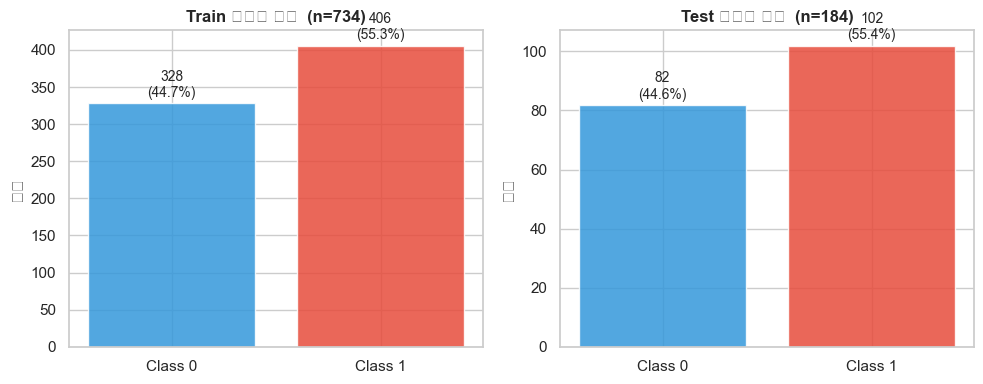

In [5]:
TEST_SIZE   = 0.2
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f'전체  : {len(X):,}건')
print(f'Train : {len(X_train):,}건  ({len(X_train)/len(X):.0%})')
print(f'Test  : {len(X_test):,}건   ({len(X_test)/len(X):.0%})')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (split_y, label) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    vc  = split_y.value_counts().sort_index()
    pct = split_y.value_counts(normalize=True).sort_index() * 100
    colors = ['#3498db', '#e74c3c']
    bars = ax.bar([f'Class {c}' for c in vc.index], vc.values,
                  color=colors[:len(vc)], alpha=0.85, edgecolor='white')
    for bar, v, p in zip(bars, vc.values, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vc.values)*0.01,
                f'{v:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{label} 클래스 분포  (n={len(split_y):,})', fontsize=12, fontweight='bold')
    ax.set_ylabel('빈도')
plt.tight_layout()
plt.show()

## 4. 모델 정의

| 모델 | 라이브러리 | 주요 하이퍼파라미터 |
|------|-----------|---------------------|
| Random Forest | scikit-learn | n_estimators=300, max_depth=None |
| XGBoost | xgboost | n_estimators=300, lr=0.05, max_depth=6 |
| LightGBM | lightgbm | n_estimators=300, lr=0.05, num_leaves=31 |
| CatBoost | catboost | iterations=300, lr=0.05, depth=6 |
| MLP | scikit-learn | (256→128→64), relu, adam, early_stopping |

In [7]:
MODELS = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_split=2,
        random_state=RANDOM_SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_SEED, eval_metric='logloss', verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        random_state=RANDOM_SEED, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        random_seed=RANDOM_SEED, verbose=0
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        solver='adam', alpha=1e-4, max_iter=500,
        early_stopping=True, validation_fraction=0.1,
        random_state=RANDOM_SEED
    ),
}

print('등록된 모델:')
for name, m in MODELS.items():
    print(f'  {name}: {m.__class__.__name__}')

등록된 모델:
  Random Forest: RandomForestClassifier
  XGBoost: XGBClassifier
  LightGBM: LGBMClassifier
  CatBoost: CatBoostClassifier
  MLP: MLPClassifier


## 5. 모델 학습

In [8]:
results = {}

print('=' * 60)
print('모델 학습 시작')
print('=' * 60)

for name, model in MODELS.items():
    print(f'\n[{name}] 학습 중...', end=' ', flush=True)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc      = accuracy_score(y_test, y_pred)
    f1_mac   = f1_score(y_test, y_pred, average='macro')
    f1_mic   = f1_score(y_test, y_pred, average='micro')
    auc      = roc_auc_score(y_test, y_prob)
    cm       = confusion_matrix(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'accuracy': acc,
        'f1_macro': f1_mac,
        'f1_micro': f1_mic,
        'auc'     : auc,
        'cm'      : cm,
        'fpr'     : fpr,
        'tpr'     : tpr,
    }
    print(f'완료  |  Acc={acc:.4f}  F1-macro={f1_mac:.4f}  AUC={auc:.4f}')

print('\n' + '=' * 60)
print('전체 학습 완료')
print('=' * 60)

모델 학습 시작

[Random Forest] 학습 중... 완료  |  Acc=0.9022  F1-macro=0.9005  AUC=0.9327

[XGBoost] 학습 중... 완료  |  Acc=0.8696  F1-macro=0.8683  AUC=0.9278

[LightGBM] 학습 중... 완료  |  Acc=0.8696  F1-macro=0.8680  AUC=0.9292

[CatBoost] 학습 중... 완료  |  Acc=0.8913  F1-macro=0.8903  AUC=0.9307

[MLP] 학습 중... 완료  |  Acc=0.8641  F1-macro=0.8620  AUC=0.9199

전체 학습 완료


## 6. 성능 평가

### 6.1 성능 지표 비교

| 지표 | 설명 |
|------|------|
| **Accuracy** | 전체 정확도 |
| **F1-macro** | 클래스별 F1의 단순 평균 (클래스 불균형 고려) |
| **F1-micro** | 전체 TP/FP/FN 합산 후 F1 계산 |
| **AUC-ROC** | ROC 곡선 아래 면적 (1에 가까울수록 좋음) |

In [9]:
_rows = []
for name, r in results.items():
    _rows.append({
        '모델'    : name,
        'Accuracy': round(r['accuracy'], 4),
        'F1-macro': round(r['f1_macro'], 4),
        'F1-micro': round(r['f1_micro'], 4),
        'AUC-ROC' : round(r['auc'], 4),
    })

metrics_df = (pd.DataFrame(_rows)
              .sort_values('AUC-ROC', ascending=False)
              .reset_index(drop=True))

def _highlight_max(s):
    is_max = s == s.max()
    return ['background-color:#d4efdf;font-weight:bold' if v else '' for v in is_max]

display(
    metrics_df.style
    .apply(_highlight_max, subset=['Accuracy', 'F1-macro', 'F1-micro', 'AUC-ROC'])
    .format({'Accuracy': '{:.4f}', 'F1-macro': '{:.4f}',
             'F1-micro': '{:.4f}', 'AUC-ROC': '{:.4f}'})
    .set_caption('모델별 성능 지표 비교  (AUC-ROC 내림차순, 초록=최고값)')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

,모델,Accuracy,F1-macro,F1-micro,AUC-ROC
0,Random Forest,0.9022,0.9005,0.9022,0.9327
1,CatBoost,0.8913,0.8903,0.8913,0.9307
2,LightGBM,0.8696,0.8680,0.8696,0.9292
3,XGBoost,0.8696,0.8683,0.8696,0.9278
4,MLP,0.8641,0.8620,0.8641,0.9199


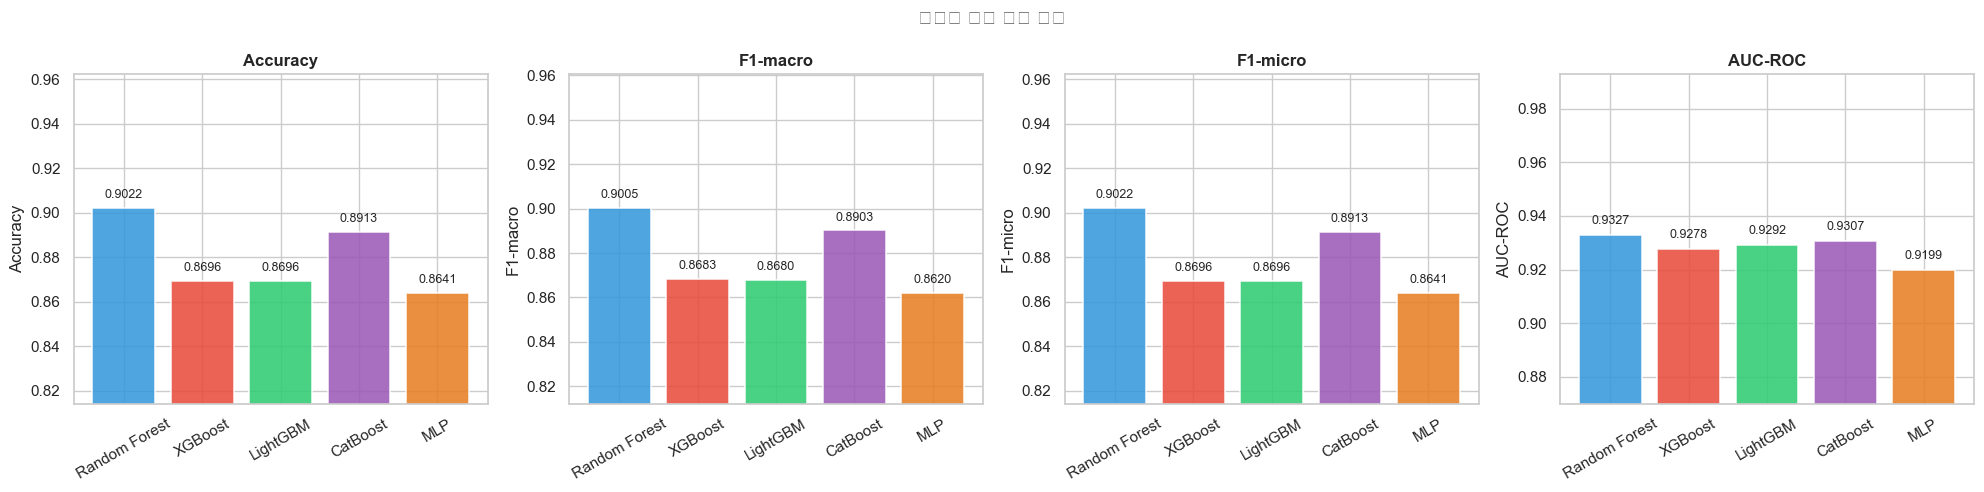

In [10]:
_metric_labels = ['Accuracy', 'F1-macro', 'F1-micro', 'AUC-ROC']
_metric_keys   = ['accuracy', 'f1_macro', 'f1_micro', 'auc']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, label, key in zip(axes, _metric_labels, _metric_keys):
    names  = list(results.keys())
    values = [results[n][key] for n in names]
    colors = [MODEL_PALETTE[n] for n in names]
    bars   = ax.bar(names, values, color=colors, alpha=0.87, edgecolor='white', linewidth=1.2)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    _ymin = max(0, min(values) - 0.05)
    ax.set_ylim(_ymin, min(1.05, max(values) + 0.06))
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel(label)

plt.suptitle('모델별 성능 지표 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 ROC Curve

FPR (False Positive Rate) 대비 TPR (True Positive Rate) 곡선.
대각선에 가까울수록 무작위 분류기 수준, 좌상단에 가까울수록 우수.

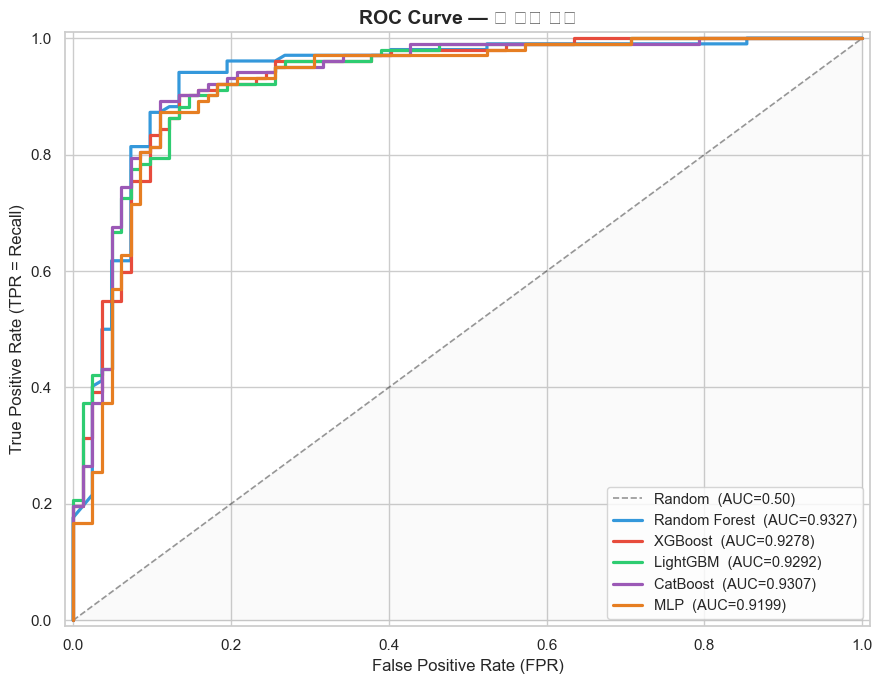

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.45, label='Random  (AUC=0.50)')

for name, r in results.items():
    ax.plot(r['fpr'], r['tpr'],
            color=MODEL_PALETTE[name], linewidth=2.3,
            label=f'{name}  (AUC={r["auc"]:.4f})')

ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=12)
ax.set_title('ROC Curve — 전 모델 비교', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10.5)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

### 6.3 Confusion Matrix

행: 실제 클래스  /  열: 예측 클래스

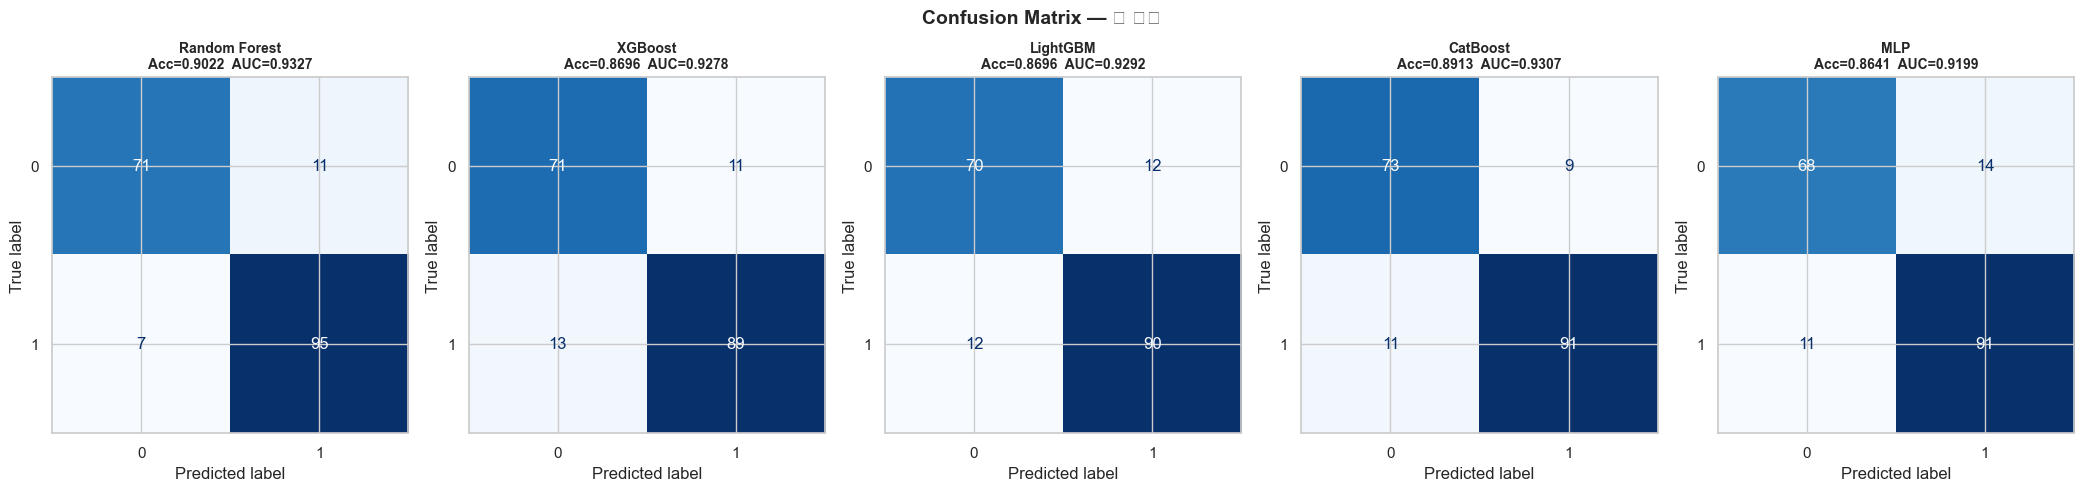

In [12]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4.2 * n_models, 4.5))

for ax, (name, r) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=r['cm'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    tn, fp, fn, tp = r['cm'].ravel()
    ax.set_title(
        f'{name}\n'
        f'Acc={r["accuracy"]:.4f}  AUC={r["auc"]:.4f}',
        fontsize=10, fontweight='bold'
    )

plt.suptitle('Confusion Matrix — 전 모델', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Classification Report

Precision · Recall · F1-score per class

In [13]:
for name, r in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, r['y_pred'],
                                target_names=[f'Class {c}' for c in sorted(y.unique())]))


  Random Forest
              precision    recall  f1-score   support

     Class 0       0.91      0.87      0.89        82
     Class 1       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184


  XGBoost
              precision    recall  f1-score   support

     Class 0       0.85      0.87      0.86        82
     Class 1       0.89      0.87      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


  LightGBM
              precision    recall  f1-score   support

     Class 0       0.85      0.85      0.85        82
     Class 1       0.88      0.88      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87 

## 7. Feature Importance

| 모델 | 방법 |
|------|------|
| Random Forest | 내장 `feature_importances_` (Mean Decrease Impurity) |
| XGBoost | 내장 `feature_importances_` (weight 기반) |
| LightGBM | 내장 `feature_importances_` (split 기반) |
| CatBoost | `get_feature_importance()` |
| MLP | Permutation Importance (n_repeats=15) |

> MLP는 내장 중요도 없음 → 테스트 셋 기반 Permutation Importance 사용

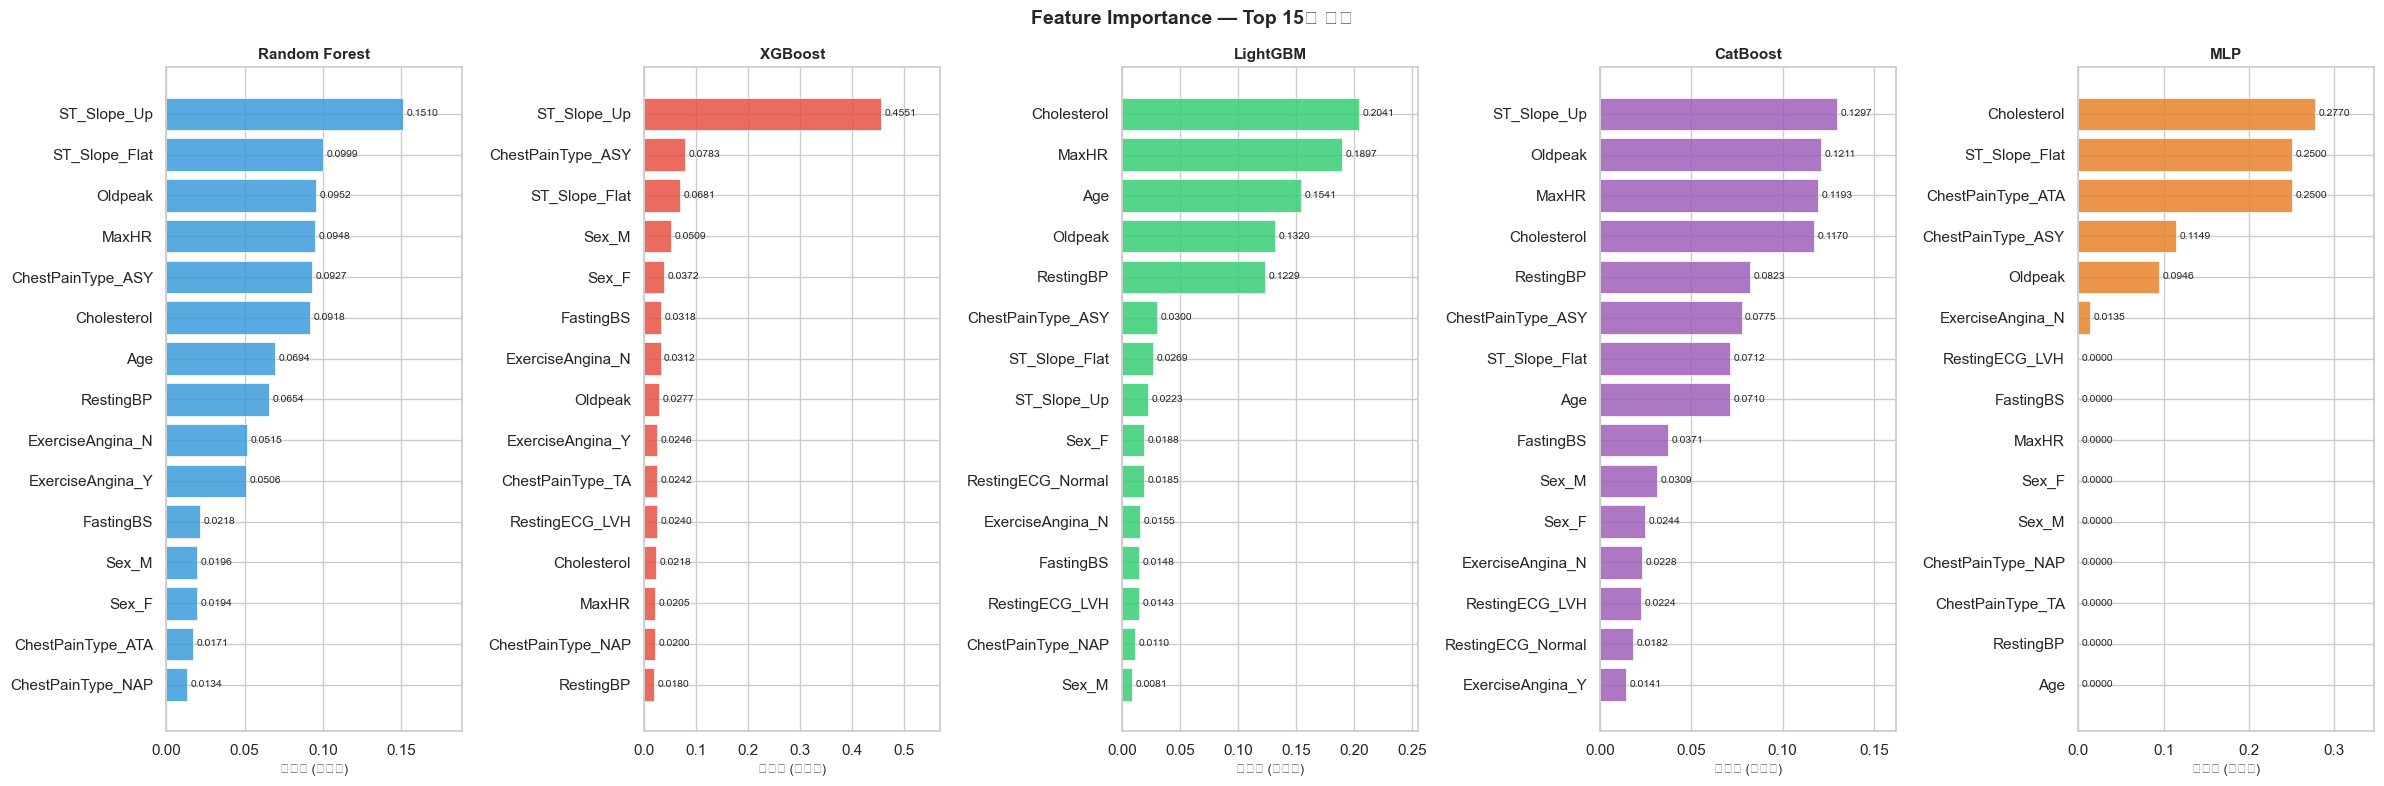

In [14]:
def get_importance(name, model, X_te, y_te, feat_names):
    """모델별 feature importance 추출 후 정규화 (합=1)."""
    if hasattr(model, 'get_feature_importance'):      # CatBoost
        imp = model.get_feature_importance()
    elif hasattr(model, 'feature_importances_'):       # RF, XGB, LGBM
        imp = model.feature_importances_
    else:                                              # MLP
        perm = permutation_importance(
            model, X_te, y_te,
            n_repeats=15, random_state=42, n_jobs=-1
        )
        imp = np.maximum(perm.importances_mean, 0)
    total = imp.sum()
    return imp / total if total > 0 else imp


N_TOP = min(15, len(feature_names))
n_models = len(results)

fig, axes = plt.subplots(1, n_models, figsize=(4.8 * n_models, 8))

for ax, (name, r) in zip(axes, results.items()):
    imp   = get_importance(name, r['model'], X_test, y_test, feature_names)
    s     = pd.Series(imp, index=feature_names)
    top_s = s.nlargest(N_TOP).sort_values(ascending=True)

    bars = ax.barh(top_s.index, top_s.values,
                   color=MODEL_PALETTE[name], alpha=0.82,
                   edgecolor='white', linewidth=0.6)
    _mx = top_s.max()
    for bar, val in zip(bars, top_s.values):
        ax.text(val + _mx * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', ha='left', fontsize=7.5)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('중요도 (정규화)', fontsize=9)
    ax.set_xlim(0, _mx * 1.25)

plt.suptitle(f'Feature Importance — Top {N_TOP}개 피처',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. 모델 성능 종합 요약

최고 성능 모델: Random Forest  (AUC=0.9327)



,모델,Accuracy,F1-macro,F1-micro,AUC-ROC,순위(AUC)
0,Random Forest,0.9022,0.9005,0.9022,0.9327,1
1,CatBoost,0.8913,0.8903,0.8913,0.9307,2
2,LightGBM,0.8696,0.8680,0.8696,0.9292,3
3,XGBoost,0.8696,0.8683,0.8696,0.9278,4
4,MLP,0.8641,0.8620,0.8641,0.9199,5


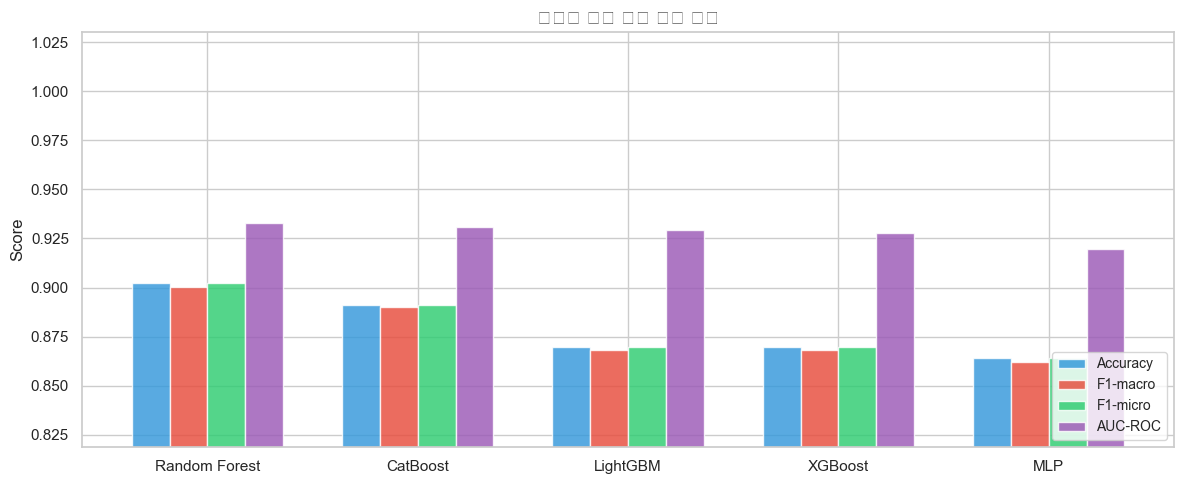


[완료] 모델링 전 구간 종료


In [15]:
# 종합 요약 테이블
_sum_rows = []
for name, r in results.items():
    _sum_rows.append({
        '모델'    : name,
        'Accuracy': round(r['accuracy'], 4),
        'F1-macro': round(r['f1_macro'], 4),
        'F1-micro': round(r['f1_micro'], 4),
        'AUC-ROC' : round(r['auc'], 4),
        '순위(AUC)': 0,
    })

summary_df = (pd.DataFrame(_sum_rows)
              .sort_values('AUC-ROC', ascending=False)
              .reset_index(drop=True))
summary_df['순위(AUC)'] = range(1, len(summary_df) + 1)

best_model_name = summary_df.iloc[0]['모델']
best_auc        = summary_df.iloc[0]['AUC-ROC']

print(f'최고 성능 모델: {best_model_name}  (AUC={best_auc:.4f})')
print()

def _highlight_best(s):
    best_idx = s.idxmax()
    return ['background-color:#d4efdf;font-weight:bold'
            if i == best_idx else '' for i in range(len(s))]

display(
    summary_df.style
    .apply(_highlight_best, subset=['Accuracy', 'F1-macro', 'F1-micro', 'AUC-ROC'])
    .format({'Accuracy': '{:.4f}', 'F1-macro': '{:.4f}',
             'F1-micro': '{:.4f}', 'AUC-ROC': '{:.4f}'})
    .set_caption(f'최종 모델 성능 요약  |  Best: {best_model_name}  (AUC={best_auc:.4f})')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)

# 레이더 스타일 종합 바차트
fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(len(summary_df))
width  = 0.18
metrics_plot = ['Accuracy', 'F1-macro', 'F1-micro', 'AUC-ROC']
offsets = np.linspace(-0.27, 0.27, len(metrics_plot))
_bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for offset, metric, color in zip(offsets, metrics_plot, _bar_colors):
    vals = summary_df[metric].values
    ax.bar(x + offset, vals, width=width, label=metric,
           color=color, alpha=0.82, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(summary_df['모델'], fontsize=11)
ax.set_ylim(summary_df[metrics_plot].values.min() * 0.95, 1.03)
ax.set_ylabel('Score')
ax.set_title('모델별 전체 성능 지표 비교', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

print('\n[완료] 모델링 전 구간 종료')